# Chapter 9 computational laboratory: tensor gauges beyond positivity

This notebook isolates one algebraic statement that becomes especially important when graphical models meet tensor networks.

For two tensors joined by one internal bond, a paired change of basis on that bond leaves the complete contraction unchanged. If $A$ carries the bond index on its last axis and $B$ carries it on its first axis, introduce an invertible matrix $G$ and transform

$$
A' = A G, \qquad B' = G^{-1} B.
$$

Then the contracted object is unchanged in exact arithmetic. The identity uses multilinearity and invertibility only; it does **not** require the entries of $A$ and $B$ to be positive. We will verify the statement for positive, signed, and complex tensors and then study the numerical price of a badly conditioned gauge.

The experiment is a compact computational companion to the discussion of tensor-network gauges in Chapter 9.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

FIGDIR = Path("figs")
FIGDIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})

rng = np.random.default_rng(7)

def contract(A, B):
    return np.tensordot(A, B, axes=([-1], [0]))

def paired_gauge(A, B, G):
    A2 = np.tensordot(A, G, axes=([-1], [0]))
    B2 = np.tensordot(np.linalg.inv(G), B, axes=([1], [0]))
    return A2, B2

def relative_error(X, Y):
    denom = max(np.linalg.norm(X.ravel()), 1e-15)
    return np.linalg.norm((X - Y).ravel()) / denom


## 1. Three tensor classes

We use the same small network topology in all cases. Only the tensor entries change:

- **positive:** the probabilistic regime in which local factors can be interpreted as nonnegative weights;
- **signed:** algebraic contractions with no local probability interpretation;
- **complex:** the natural setting for quantum amplitudes.

The exact gauge identity should survive all three.

In [2]:
bond = 5
left_shape = (3, 4, bond)
right_shape = (bond, 4, 2)

A_pos = np.exp(0.4 * rng.normal(size=left_shape))
B_pos = np.exp(0.4 * rng.normal(size=right_shape))

A_signed = rng.normal(size=left_shape)
B_signed = rng.normal(size=right_shape)

A_complex = rng.normal(size=left_shape) + 1j * rng.normal(size=left_shape)
B_complex = rng.normal(size=right_shape) + 1j * rng.normal(size=right_shape)

cases = {
    "positive": (A_pos, B_pos),
    "signed": (A_signed, B_signed),
    "complex": (A_complex, B_complex),
}

G = rng.normal(size=(bond, bond))
G += 2.5 * np.eye(bond)

for name, (A, B) in cases.items():
    C = contract(A, B)
    A2, B2 = paired_gauge(A, B, G)
    C2 = contract(A2, B2)
    err = relative_error(C, C2)
    print(f"{name:8s}: relative contraction error = {err:.3e}")
    assert err < 1e-12


positive: relative contraction error = 2.267e-16
signed  : relative contraction error = 4.606e-16
complex : relative contraction error = 3.891e-16


## 2. Conditioning is different from exactness

An exact gauge transformation can still be numerically bad. We construct gauges with prescribed singular values

$$
1,\; \kappa^{-1/4},\; \kappa^{-1/2},\; \kappa^{-3/4},\; \kappa^{-1},
$$

so the condition number is approximately $\kappa$. Exact invariance does not change with $\kappa$, but finite-precision cancellation becomes increasingly delicate.

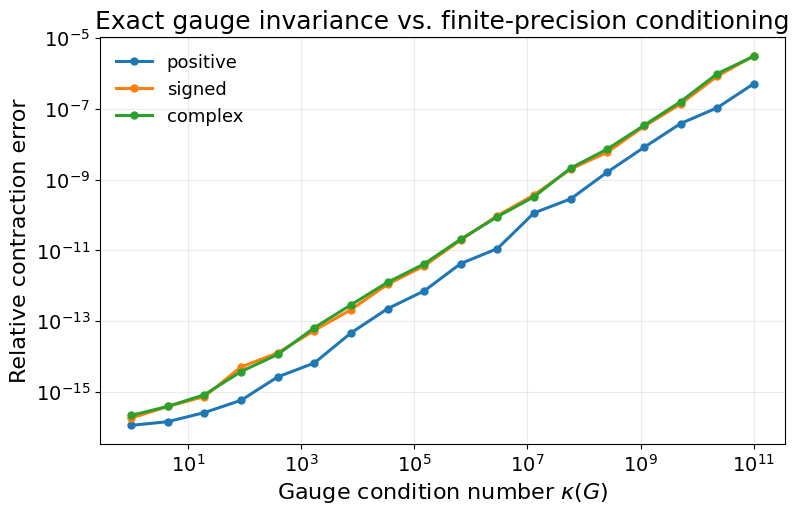

In [3]:
def random_orthogonal(n, rng):
    Q, _ = np.linalg.qr(rng.normal(size=(n, n)))
    return Q

kappas = np.logspace(0, 11, 18)
errors = {name: [] for name in cases}

U = random_orthogonal(bond, rng)
V = random_orthogonal(bond, rng)

for kappa in kappas:
    exponents = np.linspace(0.0, -1.0, bond)
    sv = kappa ** exponents
    Gk = U @ np.diag(sv) @ V.T
    for name, (A, B) in cases.items():
        C = contract(A, B)
        A2, B2 = paired_gauge(A, B, Gk)
        C2 = contract(A2, B2)
        errors[name].append(relative_error(C, C2))

fig, ax = plt.subplots(figsize=(8.2, 5.4))
for name, vals in errors.items():
    ax.loglog(kappas, vals, marker="o", linewidth=2.2, markersize=5, label=name)
ax.set_xlabel("Gauge condition number $\\kappa(G)$")
ax.set_ylabel("Relative contraction error")
ax.set_title("Exact gauge invariance vs. finite-precision conditioning")
ax.grid(True, which="both", alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGDIR / "ch09_04_gauge_conditioning.pdf", bbox_inches="tight")
fig.savefig(FIGDIR / "ch09_04_gauge_conditioning.png", dpi=220, bbox_inches="tight")
plt.show()


## Interpretation

The plot separates two questions that are easily confused.

1. **Algebraic invariance:** paired gauges preserve the exact contraction for positive, signed, and complex tensors.
2. **Numerical quality:** a poorly conditioned gauge can magnify roundoff and make an otherwise exact identity difficult to evaluate stably.

This is why gauge selection remains meaningful even after probabilistic semantics are lost. A tensor-network algorithm may choose a gauge for conditioning, low-rank compression, or truncation accuracy while preserving the exact untruncated contraction.

## Exercises and challenges

1. Replace the single internal bond by a three-tensor chain and insert independent paired gauges on both bonds. Verify invariance.
2. Repeat the experiment in single precision and compare the onset of numerical instability with double precision.
3. Construct a rank-truncated approximation after gauging. Does the gauge that minimizes the condition number also minimize truncation error?
4. **Challenge:** compare a BP-inspired gauge with a gauge optimized directly for fixed-rank tensor truncation. The exact contraction is invariant, but the approximate contraction need not be.